# Fig 4 A

In [11]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from einops import rearrange, einsum

from src.models import Transformer
from src.datasets.CopyFirstLastICLDataset import CopyFirstLastICLDataset
from src.plot_utils import format_axis

RESULTS_ROOT = Path('../../../results/icl_copy_firstlast/runs')
device = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps'  if torch.backends.mps.is_available() else
    'cpu'
)
print(f'Device: {device}')

Device: cuda


In [12]:
# replicatinon runs with same samples (20000) more 30 runs each with lr=0.0003, starting from same seed (50)
# ________ final runs in paper ________
GROUP_DIRS = [
    RESULTS_ROOT / "20260410170109_startCopyFirstFrac0.9_endCopyFirstFrac0.5_n30seeds",
    RESULTS_ROOT / "20260410170109_startCopyFirstFrac0.5_endCopyFirstFrac0.5_n30seeds",
    RESULTS_ROOT / "20260410170109_startCopyFirstFrac0.1_endCopyFirstFrac0.5_n30seeds",
]


MIN_ACC = 0.90

frac_labels = {
    0.1: 'Curriculum',
    0.5: 'Interleaved',
}


def load_group_results(group_dir: Path, min_acc: float = MIN_ACC) -> list:
    seed_results = []
    skipped = 0
    for seed_dir in sorted(group_dir.iterdir()):
        if not seed_dir.is_dir() or not seed_dir.name.startswith('seed_'):
            continue
        rf = seed_dir / 'results.json'
        if not rf.exists():
            continue
        with open(rf) as f:
            data = json.load(f)
        pt = data['pretraining']
        if max(pt['copy_first_accuracy']) < min_acc or max(pt['copy_last_accuracy']) < min_acc:
            skipped += 1
            continue
        data['_source_dir'] = str(seed_dir)
        seed_results.append(data)
    print(f'Loaded {len(seed_results)} seeds from {group_dir.name} (skipped {skipped})')
    return seed_results


def setup_seed(r: dict, device: torch.device):
    config = r['config']
    model_config = config['model']
    source_dir = Path(r['_source_dir'])
    checkpoint = torch.load(source_dir / 'pretrained_checkpoint.pt', map_location=device)
    state_dict = {k.replace('_orig_mod.', ''): v for k, v in checkpoint['model_state_dict'].items()}
    model = Transformer(**model_config)
    model.load_state_dict(state_dict)
    model = model.to(device).eval()
    eval_dataset = CopyFirstLastICLDataset(
        n_sequences=500,
        symbol_vocab_size=config['symbol_vocab_size'],
        feature_len=config['feature_len'],
        n_context_examples=config['n_context_examples'],
        task_distribution={'copy_first': 0.5, 'copy_last': 0.5},
        mode='standard',
        seed=config['seed'] + 1000,
    )
    return model, eval_dataset, config


all_seeds = {}
for group_dir in GROUP_DIRS:
    seed_results = load_group_results(group_dir)
    if not seed_results:
        continue
    frac = seed_results[0]['config']['start_copy_first_frac']
    all_seeds[frac] = seed_results
print(f'Groups loaded: {list(all_seeds.keys())}')

Loaded 30 seeds from 20260410170109_startCopyFirstFrac0.9_endCopyFirstFrac0.5_n30seeds (skipped 0)
Loaded 8 seeds from 20260410170109_startCopyFirstFrac0.5_endCopyFirstFrac0.5_n30seeds (skipped 22)
Loaded 30 seeds from 20260410170109_startCopyFirstFrac0.1_endCopyFirstFrac0.5_n30seeds (skipped 0)
Groups loaded: [0.9, 0.5, 0.1]


In [13]:
def create_corrupted_inputs(sequences, tasks, feature_len, n_context_examples):
    """
    Flip context labels: copy_first labels become feat[-1], copy_last become feat[0].
    Returns corrupted sequences (same shape as input).
    """
    corrupted = sequences.clone()
    block_size = feature_len + 3  # feat + colon + label + sep

    for i in range(n_context_examples):
        feat_start = i * block_size
        label_pos = feat_start + feature_len + 1  # position of the label token

        first_feat_pos = feat_start          # feat[0]
        last_feat_pos = feat_start + feature_len - 1  # feat[-1]

        for seq_idx in range(len(sequences)):
            task = tasks[seq_idx]
            if task == 'copy_first':
                # Currently label = feat[0], flip to feat[-1]
                corrupted[seq_idx, label_pos] = sequences[seq_idx, last_feat_pos]
            else:
                # Currently label = feat[-1], flip to feat[0]
                corrupted[seq_idx, label_pos] = sequences[seq_idx, first_feat_pos]

    return corrupted


# Verify corruption
r0 = all_seeds[list(all_seeds.keys())[0]][0]
model, eval_dataset, config = setup_seed(r0, device)
clean = eval_dataset.sequences
corrupted = create_corrupted_inputs(clean, eval_dataset.tasks, config['feature_len'], config['n_context_examples'])
fl = config['feature_len']
bs = fl + 3

# Check a few examples
for idx in range(3):
    task = eval_dataset.tasks[idx]
    print(f'Seq {idx} ({task}):')
    for ex in range(2):
        feat = clean[idx, ex*bs:ex*bs+fl].tolist()
        clean_label = clean[idx, ex*bs+fl+1].item()
        corrupt_label = corrupted[idx, ex*bs+fl+1].item()
        print(f'  Ex{ex}: feat={feat}, clean_label={clean_label} ({"first" if clean_label==feat[0] else "last"}), '
              f'corrupt_label={corrupt_label} ({"first" if corrupt_label==feat[0] else "last"})')
    print()
del model

Seq 0 (copy_first):
  Ex0: feat=[2, 35, 35, 38, 12], clean_label=2 (first), corrupt_label=12 (last)
  Ex1: feat=[21, 24, 46, 43, 37], clean_label=21 (first), corrupt_label=37 (last)

Seq 1 (copy_first):
  Ex0: feat=[23, 28, 3, 42, 27], clean_label=23 (first), corrupt_label=27 (last)
  Ex1: feat=[45, 40, 19, 17, 36], clean_label=45 (first), corrupt_label=36 (last)

Seq 2 (copy_last):
  Ex0: feat=[3, 49, 40, 22, 28], clean_label=28 (last), corrupt_label=3 (first)
  Ex1: feat=[46, 8, 2, 19, 19], clean_label=19 (last), corrupt_label=46 (first)



/tmp/ipykernel_4060452/2157138607.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(source_dir / 'pretrained_checkpoint.pt', map_location=device)


In [14]:
@torch.no_grad()
def cached_forward(model, input_ids, batch_size=64):
    """
    Run forward pass and cache intermediate activations at every edge point.

    Returns dict with keys:
        'embed':              (n, seq, d) — after embed + pos enc + dropout
        'block0_ln1_out':     (n, seq, d) — input to B0 ATT (after LN1)
        'block0_attn_out':    (n, seq, d) — B0 ATT output (before residual add)
        'block0_post_attn':   (n, seq, d) — residual after B0 ATT
        'block0_ln2_out':     (n, seq, d) — input to B0 FFN (after LN2)
        'block0_ffn_out':     (n, seq, d) — B0 FFN output
        'block0_post_ffn':    (n, seq, d) — residual after B0 FFN = input to Block 1
        'block1_ln1_out':     (n, seq, d) — input to B1 ATT (after LN1)
        'block1_attn_qkv':    (3, n, h, seq, d_head) — B1 ATT Q, K, V
        'block1_attn_out':    (n, seq, d) — B1 ATT output
        'block1_post_attn':   (n, seq, d) — residual after B1 ATT
        'block1_ln2_out':     (n, seq, d) — input to B1 FFN (after LN2)
        'block1_ffn_out':     (n, seq, d) — B1 FFN output
        'logits':             (n, vocab) — final logits at last position
    """
    model.eval()
    n_seq = input_ids.shape[0]
    cache_lists = {}

    for start in range(0, n_seq, batch_size):
        end = min(start + batch_size, n_seq)
        ids = input_ids[start:end].to(device)

        # Embedding
        tok_emb = model.token_emb(ids)
        if model.use_learned_pe:
            positions = torch.arange(ids.shape[1], device=device)
            x = tok_emb + model.pos_enc(positions)
        else:
            x = model.pos_enc(tok_emb)
        x = model.dropout(x)
        batch_cache = {'embed': x.cpu()}

        # Block 0
        b0 = model.blocks[0]
        ln1_out = b0.ln1(x)
        batch_cache['block0_ln1_out'] = ln1_out.cpu()
        attn_out = b0.attn(ln1_out)
        batch_cache['block0_attn_out'] = attn_out.cpu()
        x = x + attn_out
        batch_cache['block0_post_attn'] = x.cpu()
        ln2_out = b0.ln2(x)
        batch_cache['block0_ln2_out'] = ln2_out.cpu()
        ffn_out = b0.ff(ln2_out)
        batch_cache['block0_ffn_out'] = ffn_out.cpu()
        x = x + ffn_out
        batch_cache['block0_post_ffn'] = x.cpu()

        # Block 1 — also cache Q, K, V separately
        b1 = model.blocks[1]
        ln1_out_1 = b1.ln1(x)
        batch_cache['block1_ln1_out'] = ln1_out_1.cpu()

        # Compute Q, K, V explicitly
        qkv = b1.attn.qkv(ln1_out_1)
        q, k, v = rearrange(qkv, 'b n (three h d) -> three b h n d',
                            three=3, h=b1.attn.n_heads)
        batch_cache['block1_attn_q'] = q.cpu()
        batch_cache['block1_attn_k'] = k.cpu()
        batch_cache['block1_attn_v'] = v.cpu()

        # Complete B1 ATT
        attn_scores = einsum(q, k, 'b h i d, b h j d -> b h i j') * b1.attn.scale
        seq_len = ids.shape[1]
        causal_mask = torch.triu(torch.ones(seq_len, seq_len, device=device, dtype=torch.bool), diagonal=1)
        attn_scores = attn_scores.masked_fill(causal_mask, float('-inf'))
        attn_weights = F.softmax(attn_scores, dim=-1)
        attn_weights = b1.attn.dropout(attn_weights)
        attn_result = einsum(attn_weights, v, 'b h i j, b h j d -> b h i d')
        attn_result = rearrange(attn_result, 'b h n d -> b n (h d)')
        attn_out_1 = b1.attn.out_proj(attn_result)
        batch_cache['block1_attn_out'] = attn_out_1.cpu()
        x = x + attn_out_1
        batch_cache['block1_post_attn'] = x.cpu()

        if not b1.attention_only:
            ln2_out_1 = b1.ln2(x)
            batch_cache['block1_ln2_out'] = ln2_out_1.cpu()
            ffn_out_1 = b1.ff(ln2_out_1)
            batch_cache['block1_ffn_out'] = ffn_out_1.cpu()
            x = x + ffn_out_1

        logits = model.lm_head(model.ln_f(x))[:, -1, :]
        batch_cache['logits'] = logits.cpu()

        for k_name, v_tensor in batch_cache.items():
            cache_lists.setdefault(k_name, []).append(v_tensor)

    return {k: torch.cat(v, dim=0 if v[0].dim() >= 2 else 0) for k, v in cache_lists.items()}

In [15]:
@torch.no_grad()
def _run_b1_attn_with_qkv(model, q, k, v, pre_b1_residual, batch_size_chunk):
    """Helper: run B1 ATT with given Q, K, V and continue through B1 FFN + output."""
    b1 = model.blocks[1]
    seq_len = q.shape[2]

    attn_scores = einsum(q, k, 'b h i d, b h j d -> b h i j') * b1.attn.scale
    causal_mask = torch.triu(torch.ones(seq_len, seq_len, device=device, dtype=torch.bool), diagonal=1)
    attn_scores = attn_scores.masked_fill(causal_mask, float('-inf'))
    attn_weights = F.softmax(attn_scores, dim=-1)

    attn_result = einsum(attn_weights, v, 'b h i j, b h j d -> b h i d')
    attn_result = rearrange(attn_result, 'b h n d -> b n (h d)')
    attn_out = b1.attn.out_proj(attn_result)

    x = pre_b1_residual + attn_out

    if not b1.attention_only:
        ffn_out = b1.ff(b1.ln2(x))
        x = x + ffn_out

    return model.lm_head(model.ln_f(x))[:, -1, :]


def _patch_b1_attn_selective(model, clean_cache, corrupt_cache, corrupt_q=False, corrupt_k=False, corrupt_v=False, batch_size=64):
    """Generic helper: selectively corrupt Q, K, V inputs to B1 ATT."""
    model.eval()
    n_seq = clean_cache['embed'].shape[0]
    all_logits = []

    for start in range(0, n_seq, batch_size):
        end = min(start + batch_size, n_seq)
        q = (corrupt_cache if corrupt_q else clean_cache)['block1_attn_q'][start:end].to(device)
        k = (corrupt_cache if corrupt_k else clean_cache)['block1_attn_k'][start:end].to(device)
        v = (corrupt_cache if corrupt_v else clean_cache)['block1_attn_v'][start:end].to(device)
        residual = clean_cache['block0_post_ffn'][start:end].to(device)

        logits = _run_b1_attn_with_qkv(model, q, k, v, residual, end - start)
        all_logits.append(logits.cpu())

    return torch.cat(all_logits, dim=0)


# --- Individual patches ---

def patch_b1_attn_q(model, clean_cache, corrupt_cache, batch_size=64):
    """Corrupt Q only. Tests: does the query's 'question' matter?"""
    return _patch_b1_attn_selective(model, clean_cache, corrupt_cache, corrupt_q=True, batch_size=batch_size)

def patch_b1_attn_k(model, clean_cache, corrupt_cache, batch_size=64):
    """Corrupt K only. Tests: does content-based key matching matter?"""
    return _patch_b1_attn_selective(model, clean_cache, corrupt_cache, corrupt_k=True, batch_size=batch_size)

def patch_b1_attn_v(model, clean_cache, corrupt_cache, batch_size=64):
    """Corrupt V only. Tests: does the content read out via values matter?"""
    return _patch_b1_attn_selective(model, clean_cache, corrupt_cache, corrupt_v=True, batch_size=batch_size)

# --- Pairwise patches ---

def patch_b1_attn_qk(model, clean_cache, corrupt_cache, batch_size=64):
    """Corrupt Q and K (attention pattern). V stays clean."""
    return _patch_b1_attn_selective(model, clean_cache, corrupt_cache, corrupt_q=True, corrupt_k=True, batch_size=batch_size)

def patch_b1_attn_kv(model, clean_cache, corrupt_cache, batch_size=64):
    """Corrupt K and V (content channel). Q stays clean."""
    return _patch_b1_attn_selective(model, clean_cache, corrupt_cache, corrupt_k=True, corrupt_v=True, batch_size=batch_size)

def patch_b1_attn_qv(model, clean_cache, corrupt_cache, batch_size=64):
    """Corrupt Q and V. K stays clean."""
    return _patch_b1_attn_selective(model, clean_cache, corrupt_cache, corrupt_q=True, corrupt_v=True, batch_size=batch_size)

# --- Non-attention patches ---

@torch.no_grad()
def patch_b1_ffn_input(model, clean_cache, corrupt_cache, batch_size=64):
    """
    Resid → B1 FFN: B1 FFN reads from corrupted post-B1-ATT residual.
    Clean B1 ATT output is kept; only FFN input is corrupted.
    """
    model.eval()
    b1 = model.blocks[1]
    if b1.attention_only:
        return clean_cache['logits']

    n_seq = clean_cache['embed'].shape[0]
    all_logits = []

    for start in range(0, n_seq, batch_size):
        end = min(start + batch_size, n_seq)
        x_corrupt = corrupt_cache['block1_post_attn'][start:end].to(device)
        ffn_out = b1.ff(b1.ln2(x_corrupt))

        x_out = clean_cache['block0_post_ffn'][start:end].to(device) \
              + clean_cache['block1_attn_out'][start:end].to(device) \
              + ffn_out

        logits = model.lm_head(model.ln_f(x_out))[:, -1, :]
        all_logits.append(logits.cpu())

    return torch.cat(all_logits, dim=0)


@torch.no_grad()
def patch_b0_attn_query_colon(model, clean_cache, corrupt_cache, batch_size=64):
    """
    B0 ATT output at query colon position only.
    Replace B0 ATT's output at the last position with the corrupted version.
    """
    model.eval()
    n_seq = clean_cache['embed'].shape[0]
    all_logits = []

    for start in range(0, n_seq, batch_size):
        end = min(start + batch_size, n_seq)

        b0_attn_out = clean_cache['block0_attn_out'][start:end].clone().to(device)
        b0_attn_out[:, -1, :] = corrupt_cache['block0_attn_out'][start:end, -1, :].to(device)

        x = clean_cache['embed'][start:end].to(device) + b0_attn_out

        b0 = model.blocks[0]
        ffn_out = b0.ff(b0.ln2(x))
        x = x + ffn_out

        b1 = model.blocks[1]
        ln1_out = b1.ln1(x)
        qkv = b1.attn.qkv(ln1_out)
        q, k, v = rearrange(qkv, 'b n (three h d) -> three b h n d',
                            three=3, h=b1.attn.n_heads)
        seq_len = q.shape[2]
        attn_scores = einsum(q, k, 'b h i d, b h j d -> b h i j') * b1.attn.scale
        causal_mask = torch.triu(torch.ones(seq_len, seq_len, device=device, dtype=torch.bool), diagonal=1)
        attn_scores = attn_scores.masked_fill(causal_mask, float('-inf'))
        attn_weights = F.softmax(attn_scores, dim=-1)
        attn_result = einsum(attn_weights, v, 'b h i j, b h j d -> b h i d')
        attn_result = rearrange(attn_result, 'b h n d -> b n (h d)')
        attn_out = b1.attn.out_proj(attn_result)
        x = x + attn_out

        if not b1.attention_only:
            ffn_out_1 = b1.ff(b1.ln2(x))
            x = x + ffn_out_1

        logits = model.lm_head(model.ln_f(x))[:, -1, :]
        all_logits.append(logits.cpu())

    return torch.cat(all_logits, dim=0)


def compute_accuracy_from_logits(logits, targets, task_mask):
    """Compute accuracy for a subset of sequences given logits."""
    preds = logits.argmax(dim=-1)
    correct = (preds == targets)
    return correct[task_mask].float().mean().item()

In [16]:
# ── Denoising patch functions ──
# Base computation is corrupted; we selectively restore clean components.

def _denoise_b1_attn_selective(model, clean_cache, corrupt_cache,
                                restore_q=False, restore_k=False, restore_v=False,
                                batch_size=64):
    """Start from corrupted run, restore specified Q/K/V from clean."""
    model.eval()
    n_seq = clean_cache['embed'].shape[0]
    all_logits = []

    for start in range(0, n_seq, batch_size):
        end = min(start + batch_size, n_seq)
        q = (clean_cache if restore_q else corrupt_cache)['block1_attn_q'][start:end].to(device)
        k = (clean_cache if restore_k else corrupt_cache)['block1_attn_k'][start:end].to(device)
        v = (clean_cache if restore_v else corrupt_cache)['block1_attn_v'][start:end].to(device)
        # Residual stays corrupted
        residual = corrupt_cache['block0_post_ffn'][start:end].to(device)

        logits = _run_b1_attn_with_qkv(model, q, k, v, residual, end - start)
        all_logits.append(logits.cpu())

    return torch.cat(all_logits, dim=0)


# Individual restores
def denoise_q(model, clean_cache, corrupt_cache, batch_size=64):
    return _denoise_b1_attn_selective(model, clean_cache, corrupt_cache, restore_q=True, batch_size=batch_size)

def denoise_k(model, clean_cache, corrupt_cache, batch_size=64):
    return _denoise_b1_attn_selective(model, clean_cache, corrupt_cache, restore_k=True, batch_size=batch_size)

def denoise_v(model, clean_cache, corrupt_cache, batch_size=64):
    return _denoise_b1_attn_selective(model, clean_cache, corrupt_cache, restore_v=True, batch_size=batch_size)

# Pairwise restores
def denoise_qk(model, clean_cache, corrupt_cache, batch_size=64):
    return _denoise_b1_attn_selective(model, clean_cache, corrupt_cache, restore_q=True, restore_k=True, batch_size=batch_size)

def denoise_kv(model, clean_cache, corrupt_cache, batch_size=64):
    return _denoise_b1_attn_selective(model, clean_cache, corrupt_cache, restore_k=True, restore_v=True, batch_size=batch_size)

def denoise_qv(model, clean_cache, corrupt_cache, batch_size=64):
    return _denoise_b1_attn_selective(model, clean_cache, corrupt_cache, restore_q=True, restore_v=True, batch_size=batch_size)

# All three
def denoise_qkv(model, clean_cache, corrupt_cache, batch_size=64):
    return _denoise_b1_attn_selective(model, clean_cache, corrupt_cache, restore_q=True, restore_k=True, restore_v=True, batch_size=batch_size)


@torch.no_grad()
def denoise_b1_ffn_input(model, clean_cache, corrupt_cache, batch_size=64):
    """
    Corrupted run, but B1 FFN reads from CLEAN post-B1-ATT residual.
    Tests: is the FFN pathway sufficient when given the right input?
    """
    model.eval()
    b1 = model.blocks[1]
    if b1.attention_only:
        return corrupt_cache['logits']

    n_seq = clean_cache['embed'].shape[0]
    all_logits = []

    for start in range(0, n_seq, batch_size):
        end = min(start + batch_size, n_seq)
        # FFN reads clean input
        x_clean = clean_cache['block1_post_attn'][start:end].to(device)
        ffn_out = b1.ff(b1.ln2(x_clean))

        # But the rest of the residual is corrupted: corrupt B0 + corrupt B1 ATT + clean FFN
        x_out = corrupt_cache['block0_post_ffn'][start:end].to(device) \
              + corrupt_cache['block1_attn_out'][start:end].to(device) \
              + ffn_out

        logits = model.lm_head(model.ln_f(x_out))[:, -1, :]
        all_logits.append(logits.cpu())

    return torch.cat(all_logits, dim=0)


@torch.no_grad()
def denoise_b0_attn_all(model, clean_cache, corrupt_cache, batch_size=64):
    """
    Corrupted run, but restore clean B0 ATT output at ALL positions.
    Then re-run B0 FFN + full Block 1 from the patched residual.
    Tests: is B0 ATT the source of task information?
    """
    model.eval()
    n_seq = clean_cache['embed'].shape[0]
    all_logits = []

    for start in range(0, n_seq, batch_size):
        end = min(start + batch_size, n_seq)

        # Corrupted embed + clean B0 ATT output
        x = corrupt_cache['embed'][start:end].to(device) \
          + clean_cache['block0_attn_out'][start:end].to(device)

        # B0 FFN re-runs on this mixed residual
        b0 = model.blocks[0]
        ffn_out = b0.ff(b0.ln2(x))
        x = x + ffn_out

        # Full Block 1 from patched input
        b1 = model.blocks[1]
        ln1_out = b1.ln1(x)
        qkv = b1.attn.qkv(ln1_out)
        q, k, v = rearrange(qkv, 'b n (three h d) -> three b h n d',
                            three=3, h=b1.attn.n_heads)
        seq_len = q.shape[2]
        attn_scores = einsum(q, k, 'b h i d, b h j d -> b h i j') * b1.attn.scale
        causal_mask = torch.triu(torch.ones(seq_len, seq_len, device=device, dtype=torch.bool), diagonal=1)
        attn_scores = attn_scores.masked_fill(causal_mask, float('-inf'))
        attn_weights = F.softmax(attn_scores, dim=-1)
        attn_result = einsum(attn_weights, v, 'b h i j, b h j d -> b h i d')
        attn_result = rearrange(attn_result, 'b h n d -> b n (h d)')
        attn_out = b1.attn.out_proj(attn_result)
        x = x + attn_out

        if not b1.attention_only:
            ffn_out_1 = b1.ff(b1.ln2(x))
            x = x + ffn_out_1

        logits = model.lm_head(model.ln_f(x))[:, -1, :]
        all_logits.append(logits.cpu())

    return torch.cat(all_logits, dim=0)


@torch.no_grad()
def denoise_b0_ffn_output(model, clean_cache, corrupt_cache, batch_size=64):
    """
    Corrupted run, but restore clean B0 FFN output (leave B0 ATT corrupt).
    Sanity-check probe: does B0 FFN carry task-specialized information?
    If Block 0 is a task-agnostic shared encoder, recovery should be symmetric
    across CF and CL in every condition. Any CF/CL asymmetry would indicate
    task specialization begins earlier than Block 1.
    """
    model.eval()
    n_seq = clean_cache['embed'].shape[0]
    all_logits = []

    for start in range(0, n_seq, batch_size):
        end = min(start + batch_size, n_seq)

        # Post-Block-0 residual: corrupt embed + corrupt B0 ATT + CLEAN B0 FFN
        x = corrupt_cache['embed'][start:end].to(device) \
          + corrupt_cache['block0_attn_out'][start:end].to(device) \
          + clean_cache['block0_ffn_out'][start:end].to(device)

        # Full Block 1 on patched residual
        b1 = model.blocks[1]
        ln1_out = b1.ln1(x)
        qkv = b1.attn.qkv(ln1_out)
        q, k, v = rearrange(qkv, 'b n (three h d) -> three b h n d',
                            three=3, h=b1.attn.n_heads)
        seq_len = q.shape[2]
        attn_scores = einsum(q, k, 'b h i d, b h j d -> b h i j') * b1.attn.scale
        causal_mask = torch.triu(torch.ones(seq_len, seq_len, device=device, dtype=torch.bool), diagonal=1)
        attn_scores = attn_scores.masked_fill(causal_mask, float('-inf'))
        attn_weights = F.softmax(attn_scores, dim=-1)
        attn_result = einsum(attn_weights, v, 'b h i j, b h j d -> b h i d')
        attn_result = rearrange(attn_result, 'b h n d -> b n (h d)')
        attn_out = b1.attn.out_proj(attn_result)
        x = x + attn_out

        if not b1.attention_only:
            ffn_out_1 = b1.ff(b1.ln2(x))
            x = x + ffn_out_1

        logits = model.lm_head(model.ln_f(x))[:, -1, :]
        all_logits.append(logits.cpu())

    return torch.cat(all_logits, dim=0)


print("Denoising functions defined.")

Denoising functions defined.


In [17]:
DENOISE_PATCHES = {
    # Individual restores
    'Q': denoise_q,
    'K': denoise_k,
    'V': denoise_v,

    # Non-attention
    'L2 FFN': denoise_b1_ffn_input,
}

def _rename_regime_label(label):
    label = str(label)
    label = label.replace('Curriculum', 'Imbalanced')
    label = label.replace('curriculum', 'imbalanced')
    label = label.replace('Interleaved', 'Balanced')
    label = label.replace('interleaved', 'balanced')
    return label

denoise_results = {}

for frac in sorted(all_seeds.keys()):
    label = _rename_regime_label(frac_labels.get(frac, str(frac)))

    print(f'\n{"="*60}')
    print(f'  {label} (frac={frac})')
    print(f'{"="*60}')

    seed_records = []
    for ri, r in enumerate(all_seeds[frac]):
        model, eval_dataset, config = setup_seed(r, device)
        clean_ids = eval_dataset.sequences
        targets = eval_dataset.standard_targets
        cf_mask = torch.tensor([t == 'copy_first' for t in eval_dataset.tasks])
        cl_mask = ~cf_mask

        corrupt_ids = create_corrupted_inputs(
            clean_ids, eval_dataset.tasks,
            config['feature_len'], config['n_context_examples']
        )

        clean_cache = cached_forward(model, clean_ids)
        corrupt_cache = cached_forward(model, corrupt_ids)

        # Baselines
        clean_logits = clean_cache['logits']
        corrupt_logits = corrupt_cache['logits']
        clean_cf = compute_accuracy_from_logits(clean_logits, targets, cf_mask)
        clean_cl = compute_accuracy_from_logits(clean_logits, targets, cl_mask)
        corrupt_cf = compute_accuracy_from_logits(corrupt_logits, targets, cf_mask)
        corrupt_cl = compute_accuracy_from_logits(corrupt_logits, targets, cl_mask)

        record = {
            'clean_cf': clean_cf,
            'clean_cl': clean_cl,
            'corrupt_cf': corrupt_cf,
            'corrupt_cl': corrupt_cl,
        }

        for patch_name, patch_fn in DENOISE_PATCHES.items():
            patched_logits = patch_fn(model, clean_cache, corrupt_cache)
            cf_acc = compute_accuracy_from_logits(patched_logits, targets, cf_mask)
            cl_acc = compute_accuracy_from_logits(patched_logits, targets, cl_mask)
            record[f'{patch_name}_cf'] = cf_acc
            record[f'{patch_name}_cl'] = cl_acc

        seed_records.append(record)

        if ri % 10 == 0:
            print(
                f'  Seed {ri}: clean CF={clean_cf:.2%} CL={clean_cl:.2%}, '
                f'corrupt CF={corrupt_cf:.2%} CL={corrupt_cl:.2%}'
            )

        del model, clean_cache, corrupt_cache
        torch.cuda.empty_cache() if torch.cuda.is_available() else None

    denoise_results[frac] = {
        'label': label,
        'seeds': seed_records,
    }

print('\nDone.')


  Imbalanced (frac=0.1)


/tmp/ipykernel_4060452/2157138607.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(source_dir / 'pretrained_checkpoint.pt', map_location=device)


  Seed 0: clean CF=99.62% CL=98.74%, corrupt CF=3.07% CL=0.84%
  Seed 10: clean CF=100.00% CL=99.14%, corrupt CF=1.49% CL=2.16%
  Seed 20: clean CF=99.59% CL=98.82%, corrupt CF=3.27% CL=1.96%

  Balanced (frac=0.5)
  Seed 0: clean CF=100.00% CL=98.32%, corrupt CF=2.29% CL=4.20%

  0.9 (frac=0.9)
  Seed 0: clean CF=99.62% CL=100.00%, corrupt CF=3.07% CL=1.26%
  Seed 10: clean CF=97.76% CL=100.00%, corrupt CF=2.61% CL=4.31%
  Seed 20: clean CF=96.73% CL=99.61%, corrupt CF=2.45% CL=2.75%

Done.


In [18]:
# SD on recovery is computed per-seed (not derived from accuracy SD).
for frac in sorted(denoise_results.keys()):
    entry = denoise_results[frac]
    seeds = entry['seeds']
    n = len(seeds)
    print(f'\\n{entry["label"]} (n={n} seeds)')
    print(f'{"Patch":<17} {"CF Acc":>16} {"CL Acc":>16} {"CF Recov":>16} {"CL Recov":>16}')
    print('-' * 85)

    clean_cf_arr   = np.array([s['clean_cf']   for s in seeds])
    clean_cl_arr   = np.array([s['clean_cl']   for s in seeds])
    corrupt_cf_arr = np.array([s['corrupt_cf'] for s in seeds])
    corrupt_cl_arr = np.array([s['corrupt_cl'] for s in seeds])

    def fmt(mean, sd):
        return f'{mean:>+7.1%} ± {sd:>5.1%}'

    print(f'{"Clean":<17} {fmt(clean_cf_arr.mean(), clean_cf_arr.std()):>16} '
          f'{fmt(clean_cl_arr.mean(), clean_cl_arr.std()):>16} '
          f'{"":>16} {"":>16}')
    print(f'{"Corrupt":<17} {fmt(corrupt_cf_arr.mean(), corrupt_cf_arr.std()):>16} '
          f'{fmt(corrupt_cl_arr.mean(), corrupt_cl_arr.std()):>16} '
          f'{"(base)":>16} {"(base)":>16}')

    for patch_name in DENOISE_PATCHES:
        cf_accs = np.array([s[f'{patch_name}_cf'] for s in seeds])
        cl_accs = np.array([s[f'{patch_name}_cl'] for s in seeds])
        # Per-seed recovery (mind div-by-zero seeds)
        cf_gaps = clean_cf_arr - corrupt_cf_arr
        cl_gaps = clean_cl_arr - corrupt_cl_arr
        cf_recovs = np.where(cf_gaps > 0.01, (cf_accs - corrupt_cf_arr) / np.where(cf_gaps > 0.01, cf_gaps, 1), 0.0)
        cl_recovs = np.where(cl_gaps > 0.01, (cl_accs - corrupt_cl_arr) / np.where(cl_gaps > 0.01, cl_gaps, 1), 0.0)

        print(f'{patch_name:<17} {fmt(cf_accs.mean(),   cf_accs.std()):>16} ' f'{fmt(cl_accs.mean(),   cl_accs.std()):>16} ' f'{fmt(cf_recovs.mean(), cf_recovs.std()):>16} 'f'{fmt(cl_recovs.mean(), cl_recovs.std()):>16}')

\nImbalanced (n=30 seeds)
Patch                       CF Acc           CL Acc         CF Recov         CL Recov
-------------------------------------------------------------------------------------
Clean               +99.6% ±  0.5%   +98.4% ±  1.1%                                  
Corrupt              +3.8% ±  1.6%    +2.8% ±  1.2%           (base)           (base)
Q                    +3.8% ±  1.6%    +2.8% ±  1.2%    +0.0% ±  0.0%    +0.0% ±  0.0%
K                   +81.6% ± 20.0%   +39.8% ± 32.7%   +81.2% ± 20.7%   +39.0% ± 34.4%
V                   +22.5% ± 21.7%   +21.2% ± 20.9%   +19.7% ± 22.8%   +19.3% ± 21.6%
L2 FFN              +56.2% ± 35.5%   +88.1% ± 22.7%   +54.9% ± 37.1%   +89.3% ± 23.8%
\nBalanced (n=8 seeds)
Patch                       CF Acc           CL Acc         CF Recov         CL Recov
-------------------------------------------------------------------------------------
Clean               +99.6% ±  0.4%   +99.2% ±  0.7%                                  
Corru

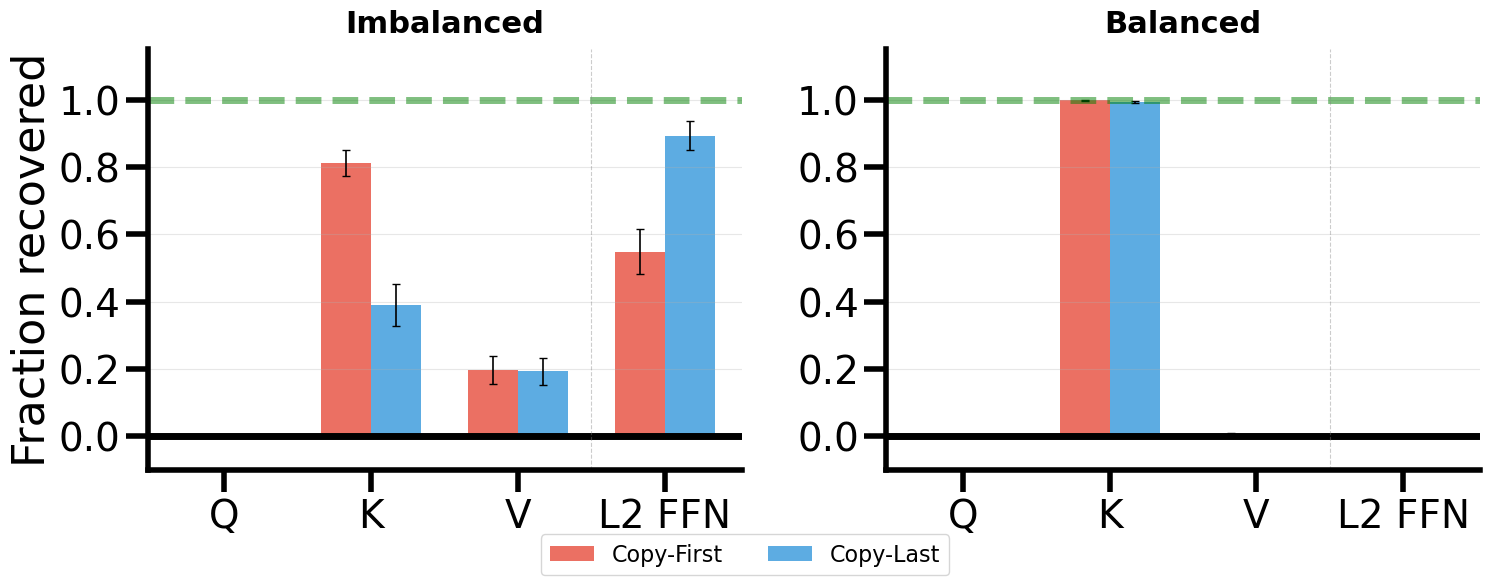

In [19]:
from matplotlib.patches import Patch

# Bar chart: denoising recovery
# Y-axis = fraction of accuracy recovered:
# 0 = corrupt baseline, 1 = full clean recovery

plot_fracs = [f for f in sorted(denoise_results.keys()) if f in (0.1, 0.5)]
dn_patch_names = list(DENOISE_PATCHES.keys())
n_dn = len(dn_patch_names)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))
axes = np.ravel(axes)

for ax_i, frac in enumerate(plot_fracs):
    ax = axes[ax_i]
    entry = denoise_results[frac]
    seeds = entry["seeds"]
    n = len(seeds)

    cf_recov = np.zeros((n, n_dn))
    cl_recov = np.zeros((n, n_dn))

    for si, s in enumerate(seeds):
        cf_gap = s["clean_cf"] - s["corrupt_cf"]
        cl_gap = s["clean_cl"] - s["corrupt_cl"]

        for pi, pname in enumerate(dn_patch_names):
            cf_recov[si, pi] = (
                (s[f"{pname}_cf"] - s["corrupt_cf"]) / cf_gap
                if cf_gap > 0.01 else 0.0
            )
            cl_recov[si, pi] = (
                (s[f"{pname}_cl"] - s["corrupt_cl"]) / cl_gap
                if cl_gap > 0.01 else 0.0
            )

    x = np.arange(n_dn)
    width = 0.34

    cf_mean = cf_recov.mean(0)
    cf_se = cf_recov.std(0) / np.sqrt(n) if n > 1 else np.zeros(n_dn)

    cl_mean = cl_recov.mean(0)
    cl_se = cl_recov.std(0) / np.sqrt(n) if n > 1 else np.zeros(n_dn)

    ax.bar(
        x - width / 2,
        cf_mean,
        width,
        yerr=cf_se,
        capsize=3,
        color="#e74c3c",
        alpha=0.8,
        error_kw={"linewidth": 1.2},
        label="Copy-First",
    )
    ax.bar(
        x + width / 2,
        cl_mean,
        width,
        yerr=cl_se,
        capsize=3,
        color="#3498db",
        alpha=0.8,
        error_kw={"linewidth": 1.2},
        label="Copy-Last",
    )

    ax.axhline(0, color="black", linewidth=0.8)
    ax.axhline(
        1,
        color="green",
        linewidth=1.0,
        linestyle="--",
        alpha=0.5,
    )

    ax.set_xticks(x)
    ax.set_xticklabels(dn_patch_names)

    if ax_i == 0:
        ax.set_ylabel("Fraction recovered")
    ax.set_ylim(-0.1, 1.15)
    ax.grid(axis="y", alpha=0.3)

    format_axis(ax, line_width_multiplier=2.0, font_size_multiplier=2)
    ax.set_title(entry["label"], fontsize=22, fontweight="bold", pad=12)

    if "L2 FFN" in dn_patch_names:
        sep_x = dn_patch_names.index("L2 FFN") - 0.5
        ax.axvline(
            sep_x,
            color="gray",
            linewidth=0.8,
            linestyle="--",
            alpha=0.4,
        )

fig.legend(
    handles=[
        Patch(facecolor="#e74c3c", alpha=0.8, label="Copy-First"),
        Patch(facecolor="#3498db", alpha=0.8, label="Copy-Last"),
    ],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=2,
    fontsize=16,
)

plt.tight_layout(w_pad=4)
fig.subplots_adjust(bottom=0.18)
plt.show()